# ORSO Example: 2-Layer NF Inference

Smoke-test the 2-layer normalizing-flow checkpoint on `exp_data/ORSO_example.ort`.

## Setup

In [7]:
%matplotlib inline

from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch

for candidate in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (candidate / "exp_data" / "ORSO_example.ort").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError("Run this notebook from inside the inverse-eval repo.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from device_utils import detect_torch_device, summarize_torch_backends
from nf_statistics import compute_nf_sample_statistics
from reflectorch import EasyInferenceModel
from simple_pipeline import _extend_prior_bounds_for_nf

plt.rcParams["text.usetex"] = False
torch.manual_seed(42)

print(f"Project root    : {PROJECT_ROOT}")
print(f"PyTorch version : {torch.__version__}")
print(f"Backends        : {summarize_torch_backends()}")

Project root    : /home/levytskyi/Documents/inverse-eval
PyTorch version : 2.7.1+cu118
Backends        : {'cuda': True, 'mps': False}


## Configuration

In [8]:
ORSO_FILE = PROJECT_ROOT / "exp_data" / "ORSO_example.ort"
VENDOR_ROOT = PROJECT_ROOT / "vendor" / "nflows_reflectorch"

NF_CONFIG = "example_nf_config_reflectorch_L2.yaml"
NF_SAMPLES = 256  # increase for final plots
DEVICE = detect_torch_device()
AMBIENT_SLD = None  # set to a value in 1e-6 A^-2 if the fronting medium is known

STRUCTURAL_PRIOR_BOUNDS = [
    (1.0, 750.0),
    (1.0, 750.0),
    (0.0, 60.0),
    (0.0, 60.0),
    (0.0, 60.0),
    (-8.0, 16.0),
    (-8.0, 16.0),
    (-8.0, 16.0),
]

PRIOR_BOUNDS = _extend_prior_bounds_for_nf(STRUCTURAL_PRIOR_BOUNDS)

print(f"ORSO file      : {ORSO_FILE}")
print(f"NF config      : {NF_CONFIG}")
print(f"Device         : {DEVICE}")
print(f"Samples        : {NF_SAMPLES}")
print(f"Prior dim      : {len(PRIOR_BOUNDS)}")

ORSO file      : /home/levytskyi/Documents/inverse-eval/exp_data/ORSO_example.ort
NF config      : example_nf_config_reflectorch_L2.yaml
Device         : cuda
Samples        : 256
Prior dim      : 10


## Load ORSO Data

In [9]:
def load_orso_curve(path: Path):
    data = np.loadtxt(path, comments="#")
    if data.ndim != 2 or data.shape[1] < 3:
        raise ValueError(f"Expected at least Q, R, dR columns in {path}")

    q = data[:, 0]
    r = data[:, 1]
    dr = data[:, 2]
    dq = data[:, 3] if data.shape[1] >= 4 else None

    mask = np.isfinite(q) & np.isfinite(r) & np.isfinite(dr) & (q > 0) & (r > 0) & (dr > 0)
    if dq is not None:
        mask &= np.isfinite(dq) & (dq >= 0)
        dq = dq[mask]

    return q[mask], r[mask], dr[mask], dq


q_exp, r_exp, dr_exp, dq_exp = load_orso_curve(ORSO_FILE)

print(f"Loaded points : {len(q_exp)}")
print(f"Q range       : {q_exp.min():.5f} - {q_exp.max():.5f} A^-1")
print(f"R range       : {r_exp.min():.3e} - {r_exp.max():.3e}")
print(f"dR/R range    : {(dr_exp / r_exp).min():.3f} - {(dr_exp / r_exp).max():.3f}")
if dq_exp is not None:
    print(f"dQ/Q median   : {np.median(dq_exp / q_exp):.4f}")

assert len(q_exp) > 0
assert np.all(np.diff(q_exp) > 0)

Loaded points : 408
Q range       : 0.00806 - 0.46555 A^-1
R range       : 9.270e-08 - 1.117e+00
dR/R range    : 0.016 - 1.784
dQ/Q median   : 0.0176


## Run Inference

In [10]:
model = EasyInferenceModel(
    config_name=NF_CONFIG,
    root_dir=str(VENDOR_ROOT),
    repo_id=None,
    device=DEVICE,
)

expected_dim = model.trainer.loader.prior_sampler.param_dim
assert len(PRIOR_BOUNDS) == expected_dim, (len(PRIOR_BOUNDS), expected_dim)

prediction = model.preprocess_and_sample(
    reflectivity_curve=r_exp,
    q_values=q_exp,
    sigmas=dr_exp,
    q_resolution=dq_exp if dq_exp is not None else 0.1,
    ambient_sld=AMBIENT_SLD,
    prior_bounds=PRIOR_BOUNDS,
    num_samples=NF_SAMPLES,
    sampling_batch_size=128,
    maximum_sim_batch_size=128,
    calc_sampled_curves=True,
    calc_sampled_sld_profiles=True,
    calc_log_likelihoods=True,
    enable_importance_sampling=True,
    clip_prediction=True,
)

print("Inference complete.")
print(f"Sampled params : {prediction['predicted_params_array'].shape}")
print(f"Sampled curves : {prediction['sampled_curves'].shape}")
print(f"Param names    : {prediction['param_names']}")

Configuration file `/home/levytskyi/Documents/inverse-eval/vendor/nflows_reflectorch/configs/example_nf_config_reflectorch_L2.yaml` found locally.
Weights file `/home/levytskyi/Documents/inverse-eval/vendor/nflows_reflectorch/saved_models/model_example_nf_config_reflectorch_L2.safetensors` found locally.
Model example_nf_config_reflectorch_L2.yaml loaded. Number of parameters: 41.64 M
The model corresponds to a `standard_model` parameterization with 2 layers (10 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 24.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained on curves discretized at exactly 256 uniform points, between q_min in [0.001, 0.02] and q_max in [0.05, 0.4]
The model was trained w

## MAP Sample

In [11]:
log_likelihoods = np.asarray(prediction["log_likelihoods"])
samples = np.asarray(prediction["predicted_params_array"])
param_names = prediction["param_names"]
best_idx = int(np.argmax(log_likelihoods))
map_params = samples[best_idx]
stats = compute_nf_sample_statistics(samples, log_likelihoods)

print(f"MAP index       : {best_idx}")
print(f"MAP loglike     : {log_likelihoods[best_idx]:.4f}")
if "ess" in prediction:
    print(f"ESS             : {prediction['ess']:.1f} / {NF_SAMPLES}")
print()
print(f"{'Parameter':<22} {'Prior min':>10} {'MAP':>12} {'Mean':>12} {'Std':>12} {'Prior max':>10}")
print("-" * 84)
for i, name in enumerate(param_names):
    lo, hi = PRIOR_BOUNDS[i]
    print(
        f"{name:<22} {lo:>10.3f} {map_params[i]:>12.4f} "
        f"{stats['nf_params_mean'][i]:>12.4f} {stats['nf_params_std'][i]:>12.4f} {hi:>10.3f}"
    )

assert samples.shape == (NF_SAMPLES, expected_dim)
assert np.isfinite(map_params).all()

MAP index       : 64
MAP loglike     : -2738.8541
ESS             : 1.0 / 256

Parameter               Prior min          MAP         Mean          Std  Prior max
------------------------------------------------------------------------------------
Thickness L2                1.000     200.2164     180.7903      58.6780    750.000
Thickness L1                1.000     292.7140     182.8525      78.0500    750.000
Roughness L2                0.000      42.4878      14.4872      11.9681     60.000
Roughness L1                0.000      10.2189      21.3242      15.9022     60.000
Roughness sub               0.000       3.5702      12.1917      15.8789     60.000
SLD L2                     -8.000      -2.1879      -2.0115       1.3680     16.000
SLD L1                     -8.000       0.1785       0.7636       1.0149     16.000
SLD sub                    -8.000       3.8599       3.9236       0.1723     16.000
r_scale                     0.900       0.9000       0.9276       0.0427      1.

## Plot Fit and SLD

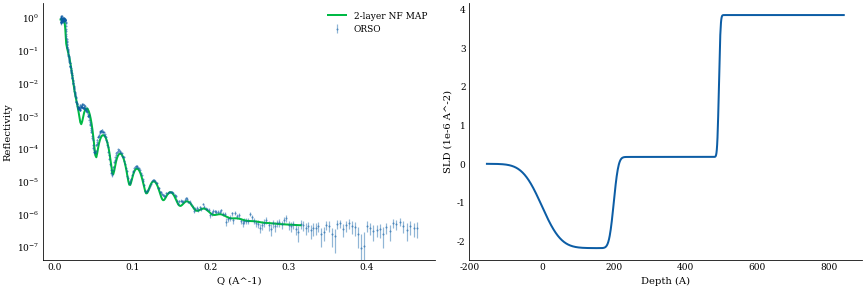

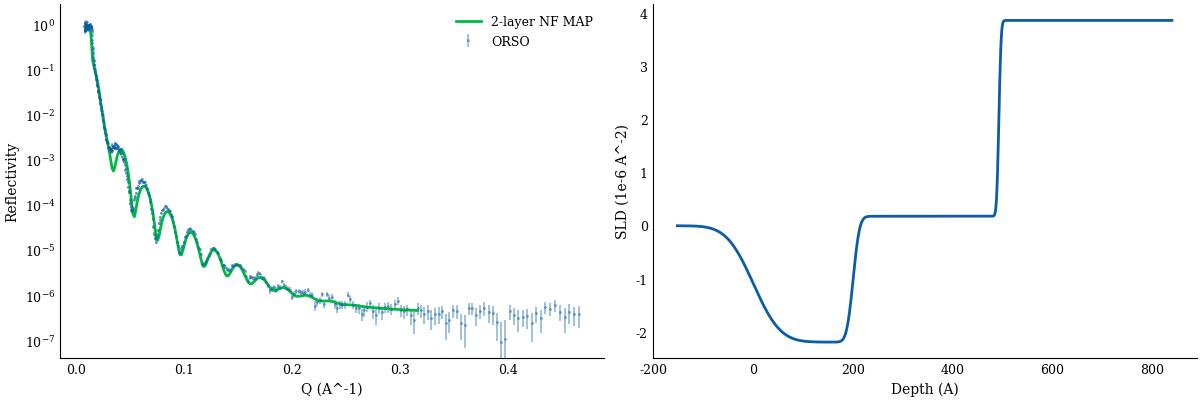

In [12]:
q_plot = np.asarray(prediction["q_plot_pred"])
curve_map = np.asarray(prediction["sampled_curves"])[best_idx]
sld_x = np.asarray(prediction["sampled_sld_xaxis"])
sld_map = np.asarray(prediction["sampled_sld_profiles"])[best_idx]

fig, (ax_r, ax_sld) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax_r.errorbar(q_exp, r_exp, yerr=dr_exp, fmt=".", ms=3, alpha=0.45, label="ORSO")
ax_r.plot(q_plot, curve_map, lw=2, label="2-layer NF MAP")
ax_r.set(xlabel="Q (A^-1)", ylabel="Reflectivity", yscale="log")
ax_r.legend()

ax_sld.plot(sld_x, sld_map, lw=2)
ax_sld.set(xlabel="Depth (A)", ylabel="SLD (1e-6 A^-2)")

plt.show()